In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from helper import speed, speedDistGaussian, get_density
from scipy.integrate import quad
import scipy.constants as con


In [42]:
m_a = 1e-6

In [ ]:
def meanLineshape(freq, T, dist, **kwargs):
    def fun(v):
        omega_v = m_a * (1 + v**2 /con.c /con.c * 1e6 / 2)
        return dist(v, **kwargs) * np.sinc((omega_v - freq) * T / 2) ** 2

    return quad(fun, 0, 600)[0] * T / 2

def coherence(dist, **kwargs):
    def fun(v):
        return dist(v, **kwargs)**2 / (v)
    return quad(fun, 0, 600)[0] * 2 * np.pi / m_a * 1e-6

In [57]:
v_c = np.array([[218, -119, 21]])

num = 5
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167]*3), num)
spd = speed(vel + v_c)

rho = []
for str_num in range(1, num+1):
    rho.append(get_density(str_num))

streams = np.column_stack([spd, rho])
streams

array([[2.68462640e+02, 3.65915325e-03],
       [2.64685108e+02, 2.44062030e-03],
       [2.60854345e+02, 1.91757733e-03],
       [2.55285263e+02, 1.61276922e-03],
       [2.57706696e+02, 1.40848336e-03]])

/tmp/ipykernel_14245/3242704945.py:6: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(fun, 0, 900)[0] * T / 2


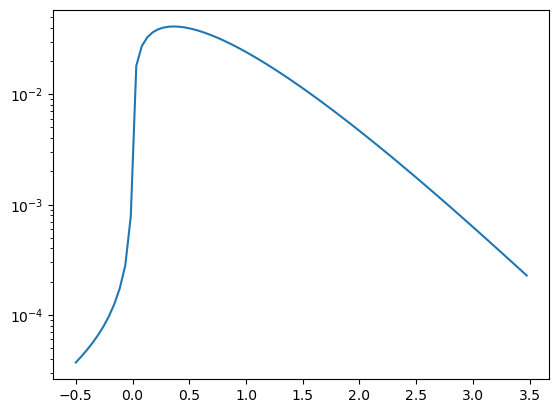

In [59]:
sig = 0.1
T_coh = coherence(speedDistGaussian, sig = 167, v_c = speed(v_c))

#meanLineshape(, T_coh, speedDistGaussian, sig=0.1, v_c =spd[0])
num = 40
ls = []

T = T_coh * con.eV / con.hbar * 2000

freq = np.arange((-0.5 *1e-6 + 1 ) * m_a, (3.5 *1e-6 + 1 ) * m_a, np.pi * 2 /T)
steps = (freq / m_a - 1) * 1e6

#freq = np.logspace(0, 1, 1000)

for i in freq:
    x = meanLineshape(i, T, speedDistGaussian, sig=167, v_c =speed(v_c))
    ls.append(x)

plt.clf()
plt.semilogy(steps, (ls)/np.sum(ls))


/tmp/ipykernel_14245/4202967538.py:4: RuntimeWarning: invalid value encountered in sqrt
  v = np.sqrt(2* freq / m_a - 2) * con.c /1e3


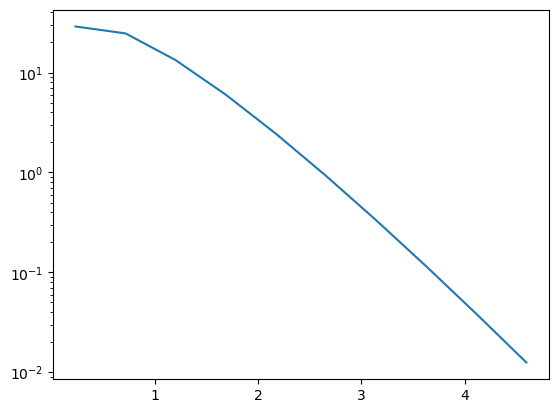

In [20]:
freq = np.arange((-0.25 *1e-6 + 1 ) * m_a, (5 *1e-6 + 1 ) * m_a, np.pi * 2 /T)
steps = (freq / m_a - 1) * 1e6

v = np.sqrt(2* freq / m_a - 2) * con.c /1e3
line = np.pi * speedDistGaussian(v, sig = 167, v_c = speed(v_c)) / v / m_a


plt.clf()
plt.semilogy(steps, line )

In [47]:
import sympy as sp

v, theta, Phi = sp.symbols('v theta Phi', positive=True, real=True)

# Energy conservation: v_infty (call it u) depends on v alone.
u = sp.sqrt(v**2 - 2*Phi)

# Local velocity components at fixed v, in terms of theta.
v_par  = v*sp.cos(theta)
v_perp = v*sp.sin(theta)


Q    = u*v_par - v_par**2 + Phi
N = (u - v_par)*v_perp
D    = u**2 - u*v_par + Phi

v_inf_par = (u* u * v_par + u * Phi - u * v_par * v_par) / D

tan_theta_inf = N/Q

d_tan_dtheta      = sp.diff(tan_theta_inf, theta)
cos2_theta_inf     = v_inf_par / u #Q**2 / (Q**2 + N**2)
dtheta_inf_dtheta = sp.simplify(cos2_theta_inf ** 2 * d_tan_dtheta)

identity_check = sp.simplify(Q**2 + N**2 - D**2)
print("Q^2 + N^2 - D^2 (should be 0):", identity_check)

print("dtheta_infty/dtheta:", sp.simplify(dtheta_inf_dtheta))

Q^2 + N^2 - D^2 (should be 0): 0
dtheta_infty/dtheta: v*(-Phi*sqrt(-2*Phi + v**2) + v**2*sqrt(-2*Phi + v**2)*cos(theta)**2 + v*(2*Phi - v**2)*cos(theta))**2*(2*Phi*v*cos(theta)**2 + Phi*v - Phi*sqrt(-2*Phi + v**2)*cos(theta) - v**3*cos(theta)**2 - v**3 + 2*v**2*sqrt(-2*Phi + v**2)*cos(theta))/((2*Phi - v**2)*(Phi - v**2 + v*sqrt(-2*Phi + v**2)*cos(theta))**2*(Phi - v**2*cos(theta)**2 + v*sqrt(-2*Phi + v**2)*cos(theta))**2)


In [62]:
sp.simplify(dtheta_inf_dtheta - 1)

(v*(-Phi*sqrt(-2*Phi + v**2) + v**2*sqrt(-2*Phi + v**2)*cos(theta)**2 + v*(2*Phi - v**2)*cos(theta))**2*(2*Phi*v*cos(theta)**2 + Phi*v - Phi*sqrt(-2*Phi + v**2)*cos(theta) - v**3*cos(theta)**2 - v**3 + 2*v**2*sqrt(-2*Phi + v**2)*cos(theta)) + (-2*Phi + v**2)*(Phi - v**2 + v*sqrt(-2*Phi + v**2)*cos(theta))**2*(Phi - v**2*cos(theta)**2 + v*sqrt(-2*Phi + v**2)*cos(theta))**2)/((2*Phi - v**2)*(Phi - v**2 + v*sqrt(-2*Phi + v**2)*cos(theta))**2*(Phi - v**2*cos(theta)**2 + v*sqrt(-2*Phi + v**2)*cos(theta))**2)

In [55]:
sp.simplify(dtheta_inf_dtheta - (1 + Phi/D))

0

In [ ]:
s = sp.solve(sp.Eq(0, dtheta_inf_dtheta), D)
s

[-sqrt(2)*sqrt(v)*sqrt((-6*Phi**3*v*cos(theta)**2 - Phi**3*v + Phi**3*sqrt(-2*Phi + v**2)*cos(theta) + 12*Phi**2*v**3*cos(theta)**4 + 15*Phi**2*v**3*cos(theta)**2 + Phi**2*v**3 - 8*Phi**2*v**2*sqrt(-2*Phi + v**2)*cos(theta)**3 - 4*Phi**2*v**2*sqrt(-2*Phi + v**2)*cos(theta) - 2*Phi*v**5*cos(theta)**6 - 17*Phi*v**5*cos(theta)**4 - 9*Phi*v**5*cos(theta)**2 + 5*Phi*v**4*sqrt(-2*Phi + v**2)*cos(theta)**5 + 13*Phi*v**4*sqrt(-2*Phi + v**2)*cos(theta)**3 + 2*Phi*v**4*sqrt(-2*Phi + v**2)*cos(theta) + v**7*cos(theta)**6 + 6*v**7*cos(theta)**4 + v**7*cos(theta)**2 - 4*v**6*sqrt(-2*Phi + v**2)*cos(theta)**5 - 4*v**6*sqrt(-2*Phi + v**2)*cos(theta)**3)/(Phi**2 - 4*Phi*v**2*cos(theta)**2 + 2*Phi*v*sqrt(-2*Phi + v**2)*cos(theta) + v**4*cos(theta)**4 + v**4*cos(theta)**2 - 2*v**3*sqrt(-2*Phi + v**2)*cos(theta)**3))/2,
 sqrt(2)*sqrt(v)*sqrt((-6*Phi**3*v*cos(theta)**2 - Phi**3*v + Phi**3*sqrt(-2*Phi + v**2)*cos(theta) + 12*Phi**2*v**3*cos(theta)**4 + 15*Phi**2*v**3*cos(theta)**2 + Phi**2*v**3 - 8*Phi**2*

In [23]:
s[1]

v**2*(sin(theta)**2 + I*cos(theta)*Abs(sin(theta)))

In [26]:
sp.simplify(s[0] * s[1])

v**4*sin(theta)**2

In [29]:
sp.simplify(D * D)

(Phi - v**2 + v*sqrt(-2*Phi + v**2)*cos(theta))**2